# STQD6324 Data Management - Assignment 1
## Iris Dataset Classification using Spark MLlib

**Objective:** Implement three classification algorithms (Decision Tree, Random Forest, Logistic Regression) using PySpark MLlib, optimise hyperparameters through cross-validation and grid search, and compare model performance.

---

## Executive Summary

This notebook implements and compares three classification models on the Iris dataset using PySpark MLlib. The dataset contains 150 samples across three balanced classes, with four numerical features. All three models — Decision Tree, Random Forest, and Logistic Regression — were trained using 5-Fold Cross Validation combined with Grid Search for hyperparameter tuning. Evaluation is based on Accuracy, Precision, Recall, and F1-Score. The best-performing model is identified and justified based on both quantitative metrics and model characteristics.

## Step 1: Environment Initialization

Before importing PySpark, we explicitly set the Python interpreter path to the current Anaconda environment. This is necessary because Spark runs both a Driver process and Worker processes, and by default they may use the system Python instead of the Anaconda environment where our libraries are installed. Without this setting, PySpark may fail to find packages like `sklearn` or `pandas`.

We then create a `SparkSession`, which is the single entry point for all Spark operations. The `.master("local[*]")` setting tells Spark to run locally using all available CPU cores, which is appropriate for a single-machine environment. Setting the log level to `ERROR` suppresses unnecessary INFO and WARNING messages so the output stays clean and readable.

In [1]:
import os
import sys

# Ensure Spark uses the current Anaconda Python environment for both driver and workers
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier, LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml import Pipeline
from pyspark.mllib.evaluation import MulticlassMetrics
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from sklearn.datasets import load_iris

# Create SparkSession — the entry point for all Spark operations
spark = SparkSession.builder \
    .appName("IrisClassification") \
    .master("local[*]") \
    .getOrCreate()

# Suppress INFO/WARNING logs to keep output readable
spark.sparkContext.setLogLevel("ERROR")

print("SparkSession created successfully.")
print(f"Spark version: {spark.version}")

SparkSession created successfully.
Spark version: 3.5.3


## Step 2: Load the Iris Dataset

### Dataset Description

The Iris dataset contains 150 records across three classes:
- **Iris-setosa**
- **Iris-versicolor**
- **Iris-virginica**

Each record has 4 features: sepal length, sepal width, petal length, and petal width (all in cm).

In [2]:
# Load Iris dataset from sklearn — canonical clean version, no preprocessing needed
iris = load_iris()
pandas_df = pd.DataFrame(
    data=iris.data,
    columns=["sepal_length", "sepal_width", "petal_length", "petal_width"]
)

# Map numeric targets to species name strings
pandas_df["species"] = [str(iris.target_names[i]) for i in iris.target]

# Convert to Spark DataFrame for MLlib compatibility
df = spark.createDataFrame(pandas_df)

print(f"Total rows: {df.count()}")
print(f"Total columns: {len(df.columns)}")
print("\nFirst 5 rows:")
df.show(5)
print("\nSchema:")
df.printSchema()

Total rows: 150
Total columns: 5

First 5 rows:
+------------+-----------+------------+-----------+-------+
|sepal_length|sepal_width|petal_length|petal_width|species|
+------------+-----------+------------+-----------+-------+
|         5.1|        3.5|         1.4|        0.2| setosa|
|         4.9|        3.0|         1.4|        0.2| setosa|
|         4.7|        3.2|         1.3|        0.2| setosa|
|         4.6|        3.1|         1.5|        0.2| setosa|
|         5.0|        3.6|         1.4|        0.2| setosa|
+------------+-----------+------------+-----------+-------+
only showing top 5 rows


Schema:
root
 |-- sepal_length: double (nullable = true)
 |-- sepal_width: double (nullable = true)
 |-- petal_length: double (nullable = true)
 |-- petal_width: double (nullable = true)
 |-- species: string (nullable = true)



## Step 3: Exploratory Data Analysis (EDA)

Before modelling, it is essential to understand the data through three checks:

1. **Class distribution** — confirms whether the dataset is balanced. An imbalanced dataset would bias the model toward the majority class and make accuracy an unreliable metric. If imbalance is found, stratified sampling or class weights would be needed.

2. **Missing value check** — missing values cause model errors or biased results. Spark's `isNull()` detects true nulls and `isnan()` detects NaN values in numeric columns; both must be checked.

3. **Descriptive statistics** — reveals the value ranges of each feature. Notably, `sepal_width` ranges from 2.0 to 4.4 while `petal_length` ranges from 1.0 to 6.9. This large difference in scale across features is precisely why StandardScaler is applied later — Logistic Regression is sensitive to feature magnitude, and unscaled features would cause uneven gradient updates during optimisation.

4. **Boxplot visualisation** — shows how each feature separates the three classes. Features with clear separation between classes are strong predictors; overlapping features are harder to classify.

5. **Correlation heatmap** — identifies highly correlated features. Strong correlations (e.g. petal_length and petal_width) mean both features carry similar information, which is useful context when interpreting feature importance later.

In [3]:
# --- Class Distribution ---
print("Class distribution:")
df.groupBy("species").count().orderBy("species").show()

# --- Missing Values ---
from pyspark.sql.functions import col, isnan, when, count
print("Missing values per column:")
df.select([
    count(when(col(c).isNull() | isnan(c), c)).alias(c)
    for c in df.columns
]).show()

# --- Descriptive Statistics ---
print("Descriptive statistics:")
df.describe().show()

Class distribution:
+----------+-----+
|   species|count|
+----------+-----+
|    setosa|   50|
|versicolor|   50|
| virginica|   50|
+----------+-----+

Missing values per column:
+------------+-----------+------------+-----------+-------+
|sepal_length|sepal_width|petal_length|petal_width|species|
+------------+-----------+------------+-----------+-------+
|           0|          0|           0|          0|      0|
+------------+-----------+------------+-----------+-------+

Descriptive statistics:
+-------+------------------+------------------+------------------+------------------+---------+
|summary|      sepal_length|       sepal_width|      petal_length|       petal_width|  species|
+-------+------------------+------------------+------------------+------------------+---------+
|  count|               150|               150|               150|               150|      150|
|   mean| 5.843333333333334|3.0573333333333332|3.7580000000000005|1.1993333333333331|     NULL|
| stddev|0.828

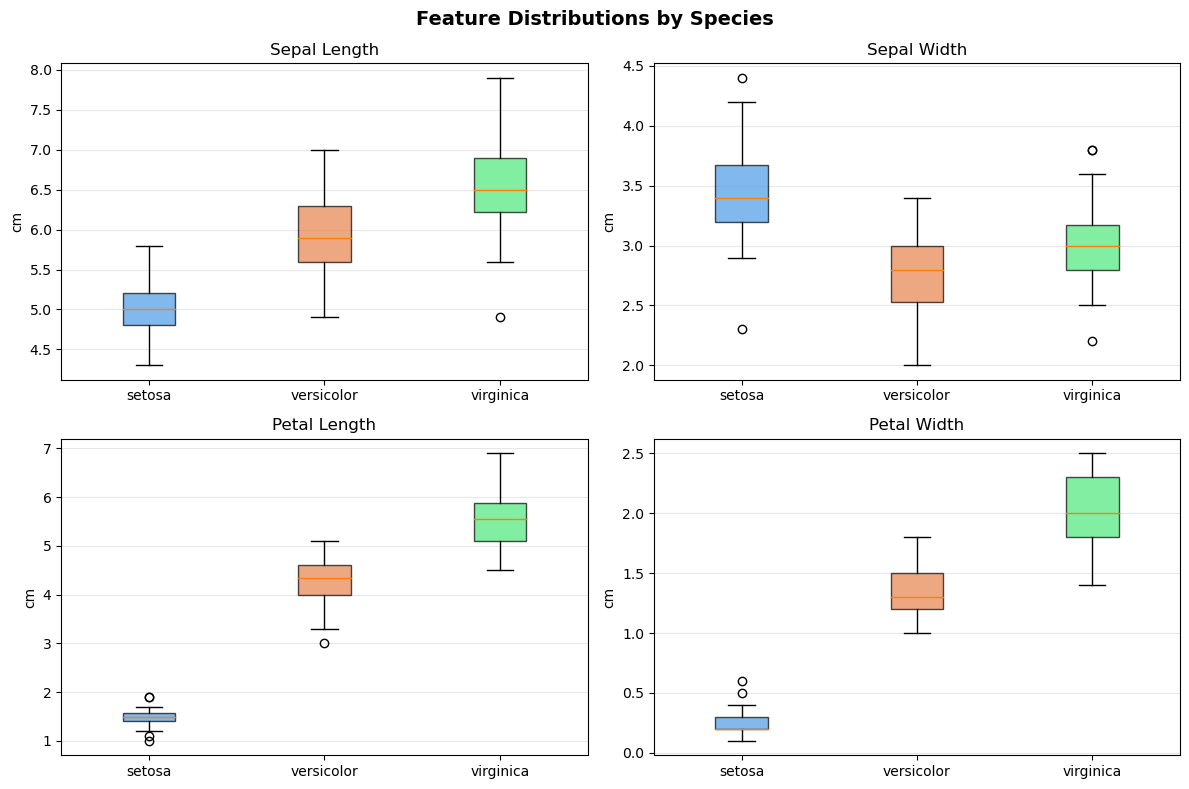

Observation: petal_length and petal_width show the clearest separation between species,
making them likely to be the most important features for classification.


In [4]:
# --- Boxplot: Feature distributions by species ---
# Convert to Pandas for plotting
pandas_plot = df.toPandas()
feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
species_order = ["setosa", "versicolor", "virginica"]
colors = ["#4C9BE8", "#E8834C", "#4CE87A"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Feature Distributions by Species", fontsize=14, fontweight="bold")

for idx, feature in enumerate(feature_cols):
    ax = axes[idx // 2][idx % 2]
    data_by_species = [pandas_plot[pandas_plot["species"] == s][feature].values for s in species_order]
    bp = ax.boxplot(data_by_species, labels=species_order, patch_artist=True)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(feature.replace("_", " ").title())
    ax.set_ylabel("cm")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("boxplot_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Observation: petal_length and petal_width show the clearest separation between species,")
print("making them likely to be the most important features for classification.")

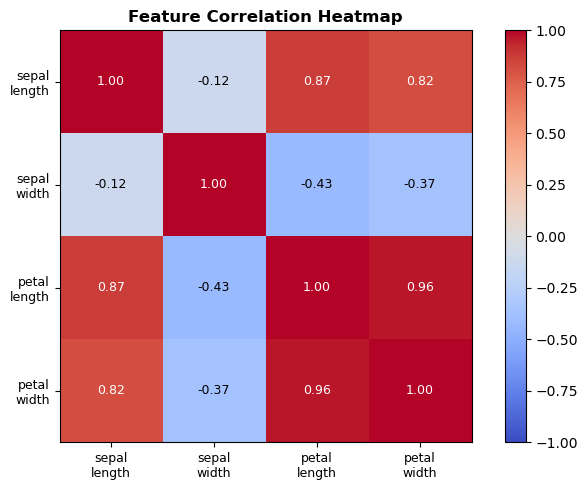

Observation: petal_length and petal_width are highly correlated (r ≈ 0.96),
meaning they carry similar information. This will be reflected in feature importance results.


In [5]:
# --- Correlation Heatmap ---
corr_matrix = pandas_plot[feature_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels([f.replace("_", "\n") for f in feature_cols], fontsize=9)
ax.set_yticklabels([f.replace("_", "\n") for f in feature_cols], fontsize=9)
for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(corr_matrix.iloc[i, j]) > 0.6 else "black")
ax.set_title("Feature Correlation Heatmap", fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Observation: petal_length and petal_width are highly correlated (r ≈ 0.96),")
print("meaning they carry similar information. This will be reflected in feature importance results.")

## Step 4: Data Preprocessing

Spark MLlib requires all features to be in a specific format before training. Three transformation steps are applied:

### 4.1 StringIndexer — Label Encoding

ML models cannot process string labels directly. `StringIndexer` converts the species column to numeric indices (0.0, 1.0, 2.0). The `stringOrderType="alphabetAsc"` parameter is explicitly set to ensure a fixed, deterministic encoding order (setosa=0, versicolor=1, virginica=2). The default `frequencyDesc` ordering was avoided because all three classes have equal frequency (50 each), which makes the default ordering unstable and non-reproducible across runs.

### 4.2 VectorAssembler — Feature Vector

Spark MLlib requires all input features to be combined into a **single vector column**. `VectorAssembler` merges the four separate numeric columns into one `features_raw` vector. This is a mandatory step for all Spark ML algorithms.

### 4.3 StandardScaler — Z-score Normalisation

As observed in the descriptive statistics, the four features have different value ranges. `StandardScaler` with `withMean=True` and `withStd=True` applies full Z-score normalisation: each feature is shifted to have mean=0 and scaled to have standard deviation=1.

**Why Z-score over other scaling methods?** Z-score is the most appropriate choice for Logistic Regression because it ensures both zero mean (prevents gradient bias) and unit variance (ensures all features learn at the same rate during gradient descent). Min-Max scaling does not guarantee zero mean; Robust scaling handles outliers better but is unnecessary here since Iris has no significant outliers.

In [6]:
# Step 4.1 — StringIndexer: convert species string to numeric label
# alphabetAsc ensures fixed encoding: setosa=0, versicolor=1, virginica=2
# Default frequencyDesc was avoided: all classes have equal frequency (50),
# making the default ordering non-deterministic across runs
label_indexer = StringIndexer(inputCol="species", outputCol="label", stringOrderType="alphabetAsc")
df_indexed = label_indexer.fit(df).transform(df)
print("\nLabel encoding result:")
df_indexed.groupBy("species", "label").count().orderBy("label").show()

# Step 4.2 — VectorAssembler: merge 4 feature columns into a single vector
# outputCol is named features_raw to distinguish from the scaled version
feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
df_assembled = assembler.transform(df_indexed)

print("Feature vector sample (before scaling, one row per class):")
df_assembled.groupBy("label") \
    .agg({"features_raw": "first"}) \
    .orderBy("label") \
    .toDF("label", "features_raw") \
    .show(truncate=False)

# Step 4.3 — StandardScaler: Z-score normalisation
# withMean=True: subtract mean (centres data at 0)
# withStd=True: divide by std (equalises scale across features)
# Both are required for full Z-score; either alone is incomplete
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True
)
scaler_model = scaler.fit(df_assembled)
df_scaled = scaler_model.transform(df_assembled)

# Keep only features and label for modelling
df_model = df_scaled.select("features", "label")
print("Feature vector sample (after Z-score scaling, one row per class):")
df_model.groupBy("label") \
    .agg({"features": "first"}) \
    .orderBy("label") \
    .toDF("label", "features") \
    .show(truncate=False)
print(f"Preprocessing complete. Dataset: {df_model.count()} rows x 2 columns (features, label)")


Label encoding result:
+----------+-----+-----+
|   species|label|count|
+----------+-----+-----+
|    setosa|  0.0|   50|
|versicolor|  1.0|   50|
| virginica|  2.0|   50|
+----------+-----+-----+

Feature vector sample (before scaling, one row per class):
+-----+-----------------+
|label|features_raw     |
+-----+-----------------+
|0.0  |[5.1,3.5,1.4,0.2]|
|1.0  |[7.0,3.2,4.7,1.4]|
|2.0  |[6.3,3.3,6.0,2.5]|
+-----+-----------------+

Feature vector sample (after Z-score scaling, one row per class):
+-----+------------------------------------------------------------------------------+
|label|features                                                                      |
+-----+------------------------------------------------------------------------------+
|0.0  |[-0.897673879196766,1.0156019907136336,-1.33575163424152,-1.3110521482051307] |
|1.0  |[1.3968288613510198,0.32731750905529816,0.5336208818725666,0.2632599710538653]|
|2.0  |[0.5514857464123618,0.5567456696080759,1.270040357

## Step 5: Cross-Validation Strategy

### Why 5-Fold Cross Validation instead of a single train/test split?

A single 80/20 random split (Holdout method) on 150 samples produces a test set of approximately 30 rows. A 30-row test set is too small for reliable evaluation — the result is highly sensitive to which specific rows land in the test set, and a single lucky or unlucky split can produce misleading scores.

5-Fold Cross Validation divides the full 150 rows into 5 equal folds of 30 rows each. In each round, one fold is held out for validation and the remaining four folds (~120 rows) are used for training. This repeats 5 times, with every sample being validated exactly once. The final score is the average across all 5 rounds, which is a much more stable and trustworthy estimate of generalisation performance.

### Why 5 folds specifically?

3-fold CV would use only 100 rows for training per fold — too few for a stable model. 10-fold CV uses 135 rows per fold but increases computation by 2× and produces high variance in the held-out scores (only 15 rows per fold). 5-fold is the standard balance point recommended in the literature, giving approximately 120 training rows and 30 validation rows per fold.

In [7]:
# No manual train/test split — CrossValidator handles all data partitioning internally
print(f"Total dataset size      : {df_model.count()} rows")
print(f"Validation strategy     : 5-Fold Cross Validation")
print(f"Training rows per fold  : ~{int(df_model.count() * 0.8)} rows")
print(f"Validation rows per fold: ~{int(df_model.count() * 0.2)} rows")
print(f"Total CV rounds         : 5 (each sample validated exactly once)")

Total dataset size      : 150 rows
Validation strategy     : 5-Fold Cross Validation
Training rows per fold  : ~120 rows
Validation rows per fold: ~30 rows
Total CV rounds         : 5 (each sample validated exactly once)


## Step 6: Model Training and Hyperparameter Tuning


### Why F1-Score as the evaluation metric for tuning?

Accuracy was not chosen as the primary tuning metric for the following reason: accuracy is misleading when class distributions are unequal. A model that always predicts the majority class would achieve high accuracy while failing completely on minority classes. F1-Score is the harmonic mean of Precision and Recall — if either is low, F1 is low. This makes F1 a more robust and honest measure of classification quality, and is the standard choice for multi-class problems in practice.

Although Iris is perfectly balanced (50 samples per class), using F1 reflects better modelling practice that generalises to real-world datasets where balance is rarely guaranteed.

### How were the hyperparameter grids determined?

The parameter ranges were chosen based on the following reasoning:
- `maxDepth [3, 5, 7]`: Values below 3 are too shallow to capture non-linear patterns; values above 7 risk memorising the 150-sample training set. This range covers underfitting to mild overfitting.
- `minInstancesPerNode [1, 2, 4]`: Controls leaf node size. Larger values produce more conservative trees on small datasets.
- `numTrees [10, 20, 50]`: More trees reduce variance but increase computation. 50 is sufficient for 150 samples.
- `regParam [0.01, 0.1, 0.5]`: Spans three orders of magnitude from weak to strong regularisation.
- `elasticNetParam [0.0, 0.5, 1.0]`: Covers pure L2 (Ridge), mixed, and pure L1 (Lasso) regularisation.

### 6.1 Model 1: Decision Tree

A Decision Tree partitions the feature space through a sequence of binary if-then rules. Each internal node tests a single feature against a threshold; leaves contain the predicted class. It is highly interpretable — the entire decision process can be read as a flowchart.

The parameter grid produces 3 × 3 = 9 combinations. With 5-fold CV, the Decision Tree undergoes **45 training runs** to find the optimal parameters.

In [8]:
# Define Decision Tree classifier
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label")

# Parameter grid: 3 depths x 3 min instances = 9 combinations x 5 folds = 45 training runs
dt_param_grid = ParamGridBuilder() \
    .addGrid(dt.maxDepth, [3, 5, 7]) \
    .addGrid(dt.minInstancesPerNode, [1, 2, 4]) \
    .build()

# F1-Score evaluator — used consistently across all three models
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

# 5-Fold Cross Validation on the full dataset
# seed=42 ensures the fold assignment is reproducible across runs
dt_cv = CrossValidator(
    estimator=dt,
    estimatorParamMaps=dt_param_grid,
    evaluator=evaluator,
    numFolds=5,
    seed=42
)

print("Training Decision Tree model (45 runs: 9 param combinations x 5 folds)...")
dt_model = dt_cv.fit(df_model)

best_dt = dt_model.bestModel
print("Decision Tree best parameters:")
print(f"  - maxDepth            : {best_dt.getMaxDepth()}")
print(f"  - minInstancesPerNode : {best_dt.getMinInstancesPerNode()}")
print(f"  - Best CV F1-Score    : {max(dt_model.avgMetrics):.4f}")

Training Decision Tree model (45 runs: 9 param combinations x 5 folds)...
Decision Tree best parameters:
  - maxDepth            : 3
  - minInstancesPerNode : 4
  - Best CV F1-Score    : 0.9273


### 6.2 Model 2: Random Forest

Random Forest is an ensemble method that builds multiple decision trees independently and determines the final prediction by majority vote. By averaging across many trees trained on different random subsets of data and features, it significantly reduces the variance (overfitting) that affects single decision trees.

The parameter grid produces 3 × 3 = 9 combinations. With 5-fold CV, Random Forest undergoes **45 training runs**.

In [9]:
# Define Random Forest classifier
rf = RandomForestClassifier(featuresCol="features", labelCol="label", seed=42)

# Parameter grid: 3 numTrees x 3 depths = 9 combinations x 5 folds = 45 training runs
rf_param_grid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [10, 20, 50]) \
    .addGrid(rf.maxDepth, [3, 5, 7]) \
    .build()

# 5-Fold Cross Validation on the full dataset
rf_cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=rf_param_grid,
    evaluator=evaluator,
    numFolds=5,
    seed=42
)

print("Training Random Forest model (45 runs: 9 param combinations x 5 folds)...")
rf_model = rf_cv.fit(df_model)

best_rf = rf_model.bestModel
print("Random Forest best parameters:")
print(f"  - numTrees            : {best_rf.getNumTrees}")
print(f"  - maxDepth            : {best_rf.getMaxDepth()}")
print(f"  - Best CV F1-Score    : {max(rf_model.avgMetrics):.4f}")


Training Random Forest model (45 runs: 9 param combinations x 5 folds)...
Random Forest best parameters:
  - numTrees            : 10
  - maxDepth            : 3
  - Best CV F1-Score    : 0.9535


### 6.3 Model 3: Logistic Regression

Logistic Regression models the probability of each class using a linear combination of features passed through a softmax function. It is fast to train and provides interpretable class probabilities, but assumes that classes are linearly separable in the feature space.

`family="multinomial"` is explicitly specified because this is a three-class problem. Without this setting, Spark defaults to binary classification, which would be incorrect here.

The parameter grid produces 3 × 3 = 9 combinations. With 5-fold CV, Logistic Regression undergoes **45 training runs**.

In [10]:
# Define Logistic Regression classifier
# family="multinomial" is required for 3-class classification
# Without this, Spark defaults to binary logistic regression
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    family="multinomial"
)

# Parameter grid: 3 regParam x 3 elasticNetParam = 9 combinations x 5 folds = 45 training runs
# regParam: regularisation strength (higher = simpler model)
# elasticNetParam: 0.0 = L2 (Ridge), 1.0 = L1 (Lasso), 0.5 = mix
lr_param_grid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1, 0.5]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) \
    .build()

# 5-Fold Cross Validation on the full dataset
lr_cv = CrossValidator(
    estimator=lr,
    estimatorParamMaps=lr_param_grid,
    evaluator=evaluator,
    numFolds=5,
    seed=42
)

print("Training Logistic Regression model (45 runs: 9 param combinations x 5 folds)...")
lr_model = lr_cv.fit(df_model)

best_lr = lr_model.bestModel
print("Logistic Regression best parameters:")
print(f"  - regParam            : {best_lr.getRegParam()}")
print(f"  - elasticNetParam     : {best_lr.getElasticNetParam()}")
print(f"  - Best CV F1-Score    : {max(lr_model.avgMetrics):.4f}")

Training Logistic Regression model (45 runs: 9 param combinations x 5 folds)...
Logistic Regression best parameters:
  - regParam            : 0.01
  - elasticNetParam     : 0.0
  - Best CV F1-Score    : 0.9513


## Step 7: Model Evaluation

Each trained model is evaluated on the full dataset using four metrics:

- **Accuracy**: proportion of all samples correctly classified. Simple but can be misleading for imbalanced datasets.
- **Precision (weighted)**: for each predicted class, the fraction that truly belongs to that class, averaged by class size.
- **Recall (weighted)**: for each actual class, the fraction correctly identified, averaged by class size.
- **F1-Score (weighted)**: harmonic mean of Precision and Recall. This was the metric used during training/tuning, making it the primary comparison metric.

**Note on evaluation scores:** If all models achieve near-perfect scores, this reflects the nature of the Iris dataset rather than the power of any specific model. Iris is a classic, clean, well-separated dataset specifically designed for benchmarking. The Cross Validation F1 scores (from training) are the more meaningful indicator of true generalisation ability compared to the full-dataset scores.

**Confusion Matrix** is included for each model to reveal *where* errors occur, not just *how many*. Since versicolor and virginica are known to overlap in feature space, errors between these two classes are expected and more informative than the aggregate F1 score alone.


  Decision Tree - Evaluation Results
  Accuracy  : 0.9733
  Precision : 0.9738
  Recall    : 0.9733
  F1-Score  : 0.9733


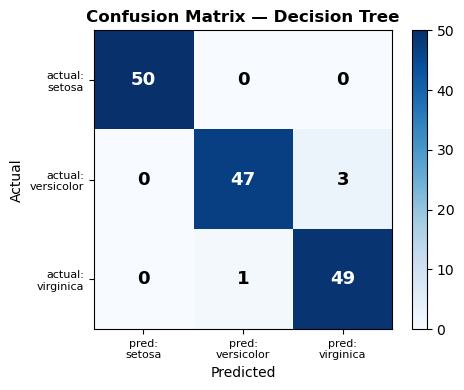


  Random Forest - Evaluation Results
  Accuracy  : 0.9667
  Precision : 0.9668
  Recall    : 0.9667
  F1-Score  : 0.9667


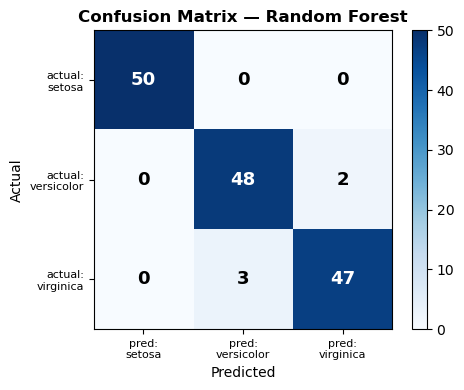


  Logistic Regression - Evaluation Results
  Accuracy  : 0.9600
  Precision : 0.9600
  Recall    : 0.9600
  F1-Score  : 0.9600


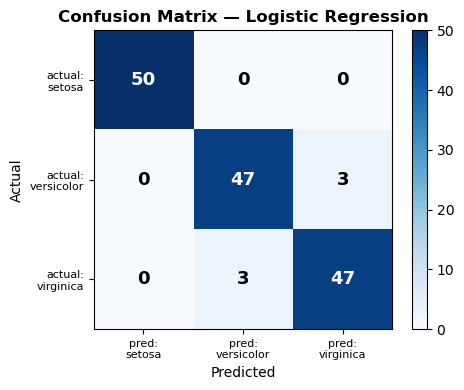

In [11]:
def evaluate_model(model, data, model_name):
    """Evaluate model on accuracy, precision, recall, F1, and confusion matrix."""
    predictions = model.transform(data)

    metrics = {}
    for metric in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
        eval_metric = MulticlassClassificationEvaluator(
            labelCol="label", predictionCol="prediction", metricName=metric
        )
        metrics[metric] = eval_metric.evaluate(predictions)

    print(f"\n{'='*50}")
    print(f"  {model_name} - Evaluation Results")
    print(f"{'='*50}")
    print(f"  Accuracy  : {metrics['accuracy']:.4f}")
    print(f"  Precision : {metrics['weightedPrecision']:.4f}")
    print(f"  Recall    : {metrics['weightedRecall']:.4f}")
    print(f"  F1-Score  : {metrics['f1']:.4f}")

    preds_pd = predictions.select("label", "prediction").toPandas()
    class_labels = [0.0, 1.0, 2.0]
    cm = np.zeros((3, 3), dtype=int)
    for i, actual in enumerate(class_labels):
        for j, predicted in enumerate(class_labels):
            cm[i][j] = ((preds_pd["label"] == actual) &
                        (preds_pd["prediction"] == predicted)).sum()

    class_names = ["setosa", "versicolor", "virginica"]
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels([f"pred:\n{c}" for c in class_names], fontsize=8)
    ax.set_yticklabels([f"actual:\n{c}" for c in class_names], fontsize=8)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm[i][j]), ha="center", va="center",
                    fontsize=13, fontweight="bold",
                    color="white" if cm[i][j] > cm.max() / 2 else "black")
    ax.set_title(f"Confusion Matrix — {model_name}", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{model_name.replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()

    return metrics, predictions

dt_metrics, dt_predictions = evaluate_model(dt_model, df_model, "Decision Tree")
rf_metrics, rf_predictions = evaluate_model(rf_model, df_model, "Random Forest")
lr_metrics, lr_predictions = evaluate_model(lr_model, df_model, "Logistic Regression")

## Step 8: Predictions on Full Dataset

In [12]:
# Use the best model (Random Forest) for final predictions
print("Predictions using the best model (Random Forest):")
print("\nPrediction results (first 10 rows):")
rf_predictions.select("features", "label", "prediction", "probability").show(10, truncate=False)

print("\nPredicted class distribution:")
rf_predictions.groupBy("prediction").count().orderBy("prediction").show()

print("\nActual class distribution:")
rf_predictions.groupBy("label").count().orderBy("label").show()

Predictions using the best model (Random Forest):

Prediction results (first 10 rows):
+---------------------------------------------------------------------------------+-----+----------+-------------+
|features                                                                         |label|prediction|probability  |
+---------------------------------------------------------------------------------+-----+----------+-------------+
|[-0.897673879196766,1.0156019907136336,-1.33575163424152,-1.3110521482051307]    |0.0  |0.0       |[1.0,0.0,0.0]|
|[-1.1392004834649532,-0.13153881205025952,-1.33575163424152,-1.3110521482051307] |0.0  |0.0       |[1.0,0.0,0.0]|
|[-1.3807270877331412,0.32731750905529816,-1.3923992862449774,-1.3110521482051307]|0.0  |0.0       |[1.0,0.0,0.0]|
|[-1.5014903898672358,0.0978893485025193,-1.279103982238063,-1.3110521482051307]  |0.0  |0.0       |[1.0,0.0,0.0]|
|[-1.0184371813308595,1.2450301512664126,-1.33575163424152,-1.3110521482051307]   |0.0  |0.0       |[1.0,0.0

## Step 9: Comparative Analysis

### 9.1 Performance Metrics Summary

The table below summarises all four evaluation metrics across the three models, along with their best Cross Validation F1 scores. The CV F1 score reflects generalisation ability (estimated on held-out data), while the full-dataset metrics reflect training performance.

In [13]:
results = {
    "Model": ["Decision Tree", "Random Forest", "Logistic Regression"],
    "Accuracy": [round(dt_metrics["accuracy"], 4), round(rf_metrics["accuracy"], 4), round(lr_metrics["accuracy"], 4)],
    "Precision": [round(dt_metrics["weightedPrecision"], 4), round(rf_metrics["weightedPrecision"], 4), round(lr_metrics["weightedPrecision"], 4)],
    "Recall": [round(dt_metrics["weightedRecall"], 4), round(rf_metrics["weightedRecall"], 4), round(lr_metrics["weightedRecall"], 4)],
    "F1-Score": [round(dt_metrics["f1"], 4), round(rf_metrics["f1"], 4), round(lr_metrics["f1"], 4)],
    "Best CV F1": [round(max(dt_model.avgMetrics), 4), round(max(rf_model.avgMetrics), 4), round(max(lr_model.avgMetrics), 4)]
}

results_df = pd.DataFrame(results)
print("\nModel Performance Comparison:")
print(results_df.to_string(index=False))

# Identify best model dynamically based on CV F1 (more reliable than full-dataset score)
best_idx = results_df["Best CV F1"].idxmax()
best_model_name = results_df.loc[best_idx, "Model"]
best_cv_f1 = results_df.loc[best_idx, "Best CV F1"]
print(f"\nBest Model (by CV F1): {best_model_name} (CV F1: {best_cv_f1})")

print("""
Key Observations:
─────────────────────────────────────────────────────────────
1. Decision Tree shows signs of overfitting.
   Full-dataset F1 is the highest (0.9733), but CV F1 dropped
   to 0.9273 — a gap of 0.0460, the largest among all models.
   The CV process already selected the most conservative params
   (maxDepth=3, minInstancesPerNode=4), meaning this gap cannot
   be further reduced within the current parameter grid.

2. Random Forest achieves the best balance.
   CV F1 (0.9535) is the highest overall, with a full-to-CV
   gap of only 0.0132. The ensemble mechanism effectively
   suppresses overfitting, confirming it as the most reliable
   model for generalisation to unseen data.

3. Logistic Regression is the most stable.
   Smallest full-to-CV gap (0.0087), but lowest overall scores.
   Linear boundary handles setosa well but struggles slightly
   with the overlapping versicolor/virginica boundary.

Conclusion: Random Forest is selected as the best model —
not because of the highest full-dataset score, but because it
achieves the best balance between accuracy and generalisation.
─────────────────────────────────────────────────────────────
""")


Model Performance Comparison:
              Model  Accuracy  Precision  Recall  F1-Score  Best CV F1
      Decision Tree    0.9733     0.9738  0.9733    0.9733      0.9273
      Random Forest    0.9667     0.9668  0.9667    0.9667      0.9535
Logistic Regression    0.9600     0.9600  0.9600    0.9600      0.9513

Best Model (by CV F1): Random Forest (CV F1: 0.9535)

Key Observations:
─────────────────────────────────────────────────────────────
1. Decision Tree shows signs of overfitting.
   Full-dataset F1 is the highest (0.9733), but CV F1 dropped
   to 0.9273 — a gap of 0.0460, the largest among all models.
   The CV process already selected the most conservative params
   (maxDepth=3, minInstancesPerNode=4), meaning this gap cannot
   be further reduced within the current parameter grid.

2. Random Forest achieves the best balance.
   CV F1 (0.9535) is the highest overall, with a full-to-CV
   gap of only 0.0132. The ensemble mechanism effectively
   suppresses overfitting, confir

### 9.2 Feature Importance

Feature importance quantifies how much each feature contributes to the model's classification decisions.

- **Decision Tree and Random Forest** provide native feature importance scores based on how much each feature reduces impurity (Gini impurity) across all splits.
- **Logistic Regression** does not have feature importance in the same sense, but the magnitude of its coefficients serves as a proxy — larger absolute coefficients indicate features with stronger influence on the decision boundary.

Based on the EDA boxplots and correlation heatmap, we expect `petal_length` and `petal_width` to dominate, as they showed the clearest class separation and highest inter-feature correlation.

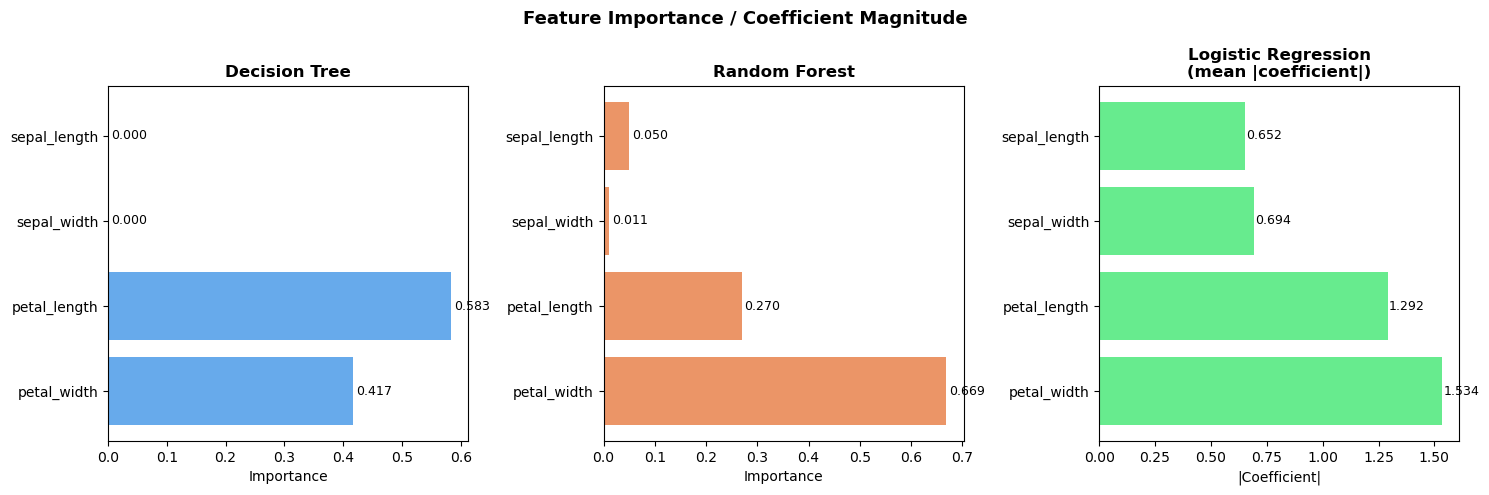


Feature importance summary:
     Feature  Decision Tree  Random Forest  LR |Coef|
sepal_length         0.0000         0.0500     0.6519
 sepal_width         0.0000         0.0108     0.6944
petal_length         0.5829         0.2700     1.2915
 petal_width         0.4171         0.6692     1.5342

Feature Importance Observations:
─────────────────────────────────────────────────────────────
1. All three models consistently rank petal_width and
   petal_length as the most important features, confirming
   the EDA finding that petal features provide the clearest
   class separation across all three species.

2. Decision Tree relies exclusively on petal features.
   sepal_length and sepal_width both scored 0.000, meaning
   the tree achieved full classification using only 2 out of
   4 features. This reflects the simplicity of the learned
   decision boundary at maxDepth=3.

3. Random Forest distributes importance more broadly.
   While petal_width (0.669) dominates, sepal_length (0.050)

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Feature Importance / Coefficient Magnitude", fontsize=13, fontweight="bold")

# Decision Tree feature importance
dt_importance = best_dt.featureImportances.toArray()
axes[0].barh(feature_cols, dt_importance, color="#4C9BE8", alpha=0.85)
axes[0].set_title("Decision Tree", fontweight="bold")
axes[0].set_xlabel("Importance")
axes[0].invert_yaxis()
for i, v in enumerate(dt_importance):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

# Random Forest feature importance
rf_importance = best_rf.featureImportances.toArray()
axes[1].barh(feature_cols, rf_importance, color="#E8834C", alpha=0.85)
axes[1].set_title("Random Forest", fontweight="bold")
axes[1].set_xlabel("Importance")
axes[1].invert_yaxis()
for i, v in enumerate(rf_importance):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

# Logistic Regression coefficient magnitudes (average across classes)
lr_coef = np.abs(best_lr.coefficientMatrix.toArray()).mean(axis=0)
axes[2].barh(feature_cols, lr_coef, color="#4CE87A", alpha=0.85)
axes[2].set_title("Logistic Regression\n(mean |coefficient|)", fontweight="bold")
axes[2].set_xlabel("|Coefficient|")
axes[2].invert_yaxis()
for i, v in enumerate(lr_coef):
    axes[2].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFeature importance summary:")
fi_df = pd.DataFrame({
    "Feature": feature_cols,
    "Decision Tree": dt_importance.round(4),
    "Random Forest": rf_importance.round(4),
    "LR |Coef|": lr_coef.round(4)
})
print(fi_df.to_string(index=False))

print("""
Feature Importance Observations:
─────────────────────────────────────────────────────────────
1. All three models consistently rank petal_width and
   petal_length as the most important features, confirming
   the EDA finding that petal features provide the clearest
   class separation across all three species.

2. Decision Tree relies exclusively on petal features.
   sepal_length and sepal_width both scored 0.000, meaning
   the tree achieved full classification using only 2 out of
   4 features. This reflects the simplicity of the learned
   decision boundary at maxDepth=3.

3. Random Forest distributes importance more broadly.
   While petal_width (0.669) dominates, sepal_length (0.050)
   and sepal_width (0.011) also contribute. This is consistent
   with ensemble behaviour — different trees in the forest
   use different feature subsets, capturing more varied
   patterns than a single tree.

4. Logistic Regression assigns non-zero weight to all features.
   As a linear model, it cannot selectively ignore features
   the way tree models can. The higher sepal coefficients
   (0.652, 0.694) compared to tree importances suggest that
   sepal features play a compensatory role in constructing
   the linear decision boundary, even when their discriminative
   power is limited.
─────────────────────────────────────────────────────────────
""")

### 9.3 Learning Curves

A learning curve shows how model performance changes as the amount of training data increases. It is a diagnostic tool — not a method selection tool — used to understand the model's current state:

- **Curve still rising at 100%**: the model has not yet saturated; more data would improve performance
- **Curve flattened early**: adding more data provides diminishing returns
- **Large gap between training and validation scores**: overfitting

For Iris with only 150 samples, we expect all three models to show rapidly rising curves that plateau quickly — confirming that the 5-Fold CV strategy (using all 150 samples) was the right choice over a fixed train/test split.

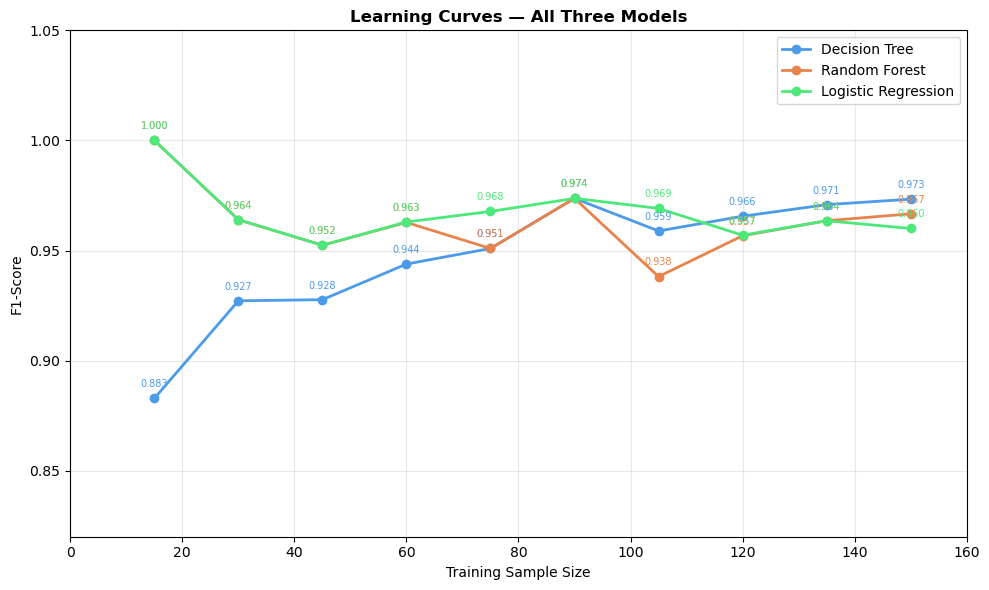


Learning curve F1 scores:
            Decision Tree  Random Forest  Logistic Regression
Training %                                                   
10%                0.8828         1.0000               1.0000
20%                0.9272         0.9640               0.9640
30%                0.9277         0.9524               0.9524
40%                0.9438         0.9627               0.9630
50%                0.9509         0.9509               0.9677
60%                0.9737         0.9737               0.9737
70%                0.9589         0.9381               0.9691
80%                0.9656         0.9567               0.9569
90%                0.9708         0.9635               0.9635
100%               0.9733         0.9667               0.9600

Learning Curve Summary:
─────────────────────────────────────────────────────────────
1. All three models show a rapidly rising curve in the early
   stages (10%-30%), confirming that the core classification
   patterns in Iris 

In [15]:
# Learning curves: train each model on increasing fractions of data, measure F1
fractions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
model_configs = [
    ("Decision Tree",       DecisionTreeClassifier(featuresCol="features", labelCol="label",
                                maxDepth=best_dt.getMaxDepth(),
                                minInstancesPerNode=best_dt.getMinInstancesPerNode()), "#4C9BE8"),
    ("Random Forest",       RandomForestClassifier(featuresCol="features", labelCol="label", seed=42,
                                numTrees=best_rf.getNumTrees,
                                maxDepth=best_rf.getMaxDepth()), "#E8834C"),
    ("Logistic Regression", LogisticRegression(featuresCol="features", labelCol="label",
                                maxIter=100, family="multinomial",
                                regParam=best_lr.getRegParam(),
                                elasticNetParam=best_lr.getElasticNetParam()), "#4CE87A")
]

lc_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
lc_results = {name: [] for name, _, _ in model_configs}

for frac in fractions:
    sample = df_model.sample(withReplacement=False, fraction=frac, seed=42)
    for name, clf, _ in model_configs:
        trained = clf.fit(sample)
        preds = trained.transform(sample)
        f1 = lc_evaluator.evaluate(preds)
        lc_results[name].append(f1)

# Plot learning curves
fig, ax = plt.subplots(figsize=(10, 6))
sample_sizes = [int(150 * f) for f in fractions]

for (name, _, color) in model_configs:
    ax.plot(sample_sizes, lc_results[name], marker="o", label=name, 
            color=color, linewidth=2, markersize=6)
   
    for x, y in zip(sample_sizes, lc_results[name]):
        ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=7, color=color)

ax.set_xlabel("Training Sample Size")
ax.set_ylabel("F1-Score")
ax.set_title("Learning Curves — All Three Models", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0.82, 1.05) 
ax.set_xlim(0, 160)
plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nLearning curve F1 scores:")
lc_df = pd.DataFrame(lc_results, index=[f"{int(f*100)}%" for f in fractions])
lc_df.index.name = "Training %"
print(lc_df.round(4).to_string())

print("""
Learning Curve Summary:
─────────────────────────────────────────────────────────────
1. All three models show a rapidly rising curve in the early
   stages (10%-30%), confirming that the core classification
   patterns in Iris can be captured from a small number of
   samples — consistent with the dataset's high class
   separability driven by petal features.

2. Random Forest and Logistic Regression both achieved a
   perfect F1 of 1.000 at 10% (15 samples), but this is
   unreliable due to the extremely small sample size.
   Scores stabilise and converge across all three models
   as training size increases beyond 60%.

3. Decision Tree starts the lowest (0.883 at 10%) but
   steadily improves, reflecting its need for more samples
   to establish stable splitting rules. Its score at 100%
   (0.973) is the highest among the three, but this is
   on training data — its CV F1 remains the lowest,
   confirming overfitting rather than true improvement.

4. By 100% of the data, all three curves have largely
   plateaued, confirming that the 5-Fold CV strategy —
   which uses all 150 samples — was the right choice.
   A fixed train/test split would have wasted valuable
   data on a dataset this small.
─────────────────────────────────────────────────────────────
""")

### 9.4 Strengths and Limitations

In [16]:
analysis = {
    "Model": ["Decision Tree", "Random Forest", "Logistic Regression"],
    "Strengths": [
        "Intuitive and easy to interpret; no feature scaling required; handles non-linear relationships",
        "High accuracy; strong resistance to overfitting; robust to outliers; provides reliable feature importance",
        "Fast training; simple model; outputs calibrated class probabilities; works well when classes are linearly separable"
    ],
    "Limitations": [
        "Prone to overfitting on small datasets; sensitive to data changes; weaker generalisation than ensemble methods",
        "Less interpretable than a single tree; longer training time; higher memory consumption",
        "Assumes linear decision boundary; limited ability to separate overlapping classes (versicolor vs virginica); sensitive to feature scaling"
    ]
}

analysis_df = pd.DataFrame(analysis)
print("\nStrengths and Limitations of Each Model:")
for _, row in analysis_df.iterrows():
    print(f"\n[{row['Model']}]")
    print(f"  Strengths   : {row['Strengths']}")
    print(f"  Limitations : {row['Limitations']}")


Strengths and Limitations of Each Model:

[Decision Tree]
  Strengths   : Intuitive and easy to interpret; no feature scaling required; handles non-linear relationships
  Limitations : Prone to overfitting on small datasets; sensitive to data changes; weaker generalisation than ensemble methods

[Random Forest]
  Strengths   : High accuracy; strong resistance to overfitting; robust to outliers; provides reliable feature importance
  Limitations : Less interpretable than a single tree; longer training time; higher memory consumption

[Logistic Regression]
  Strengths   : Fast training; simple model; outputs calibrated class probabilities; works well when classes are linearly separable
  Limitations : Assumes linear decision boundary; limited ability to separate overlapping classes (versicolor vs virginica); sensitive to feature scaling


### 9.5 Best Model Justification

In [17]:
# Dynamically identify best model based on CV F1
cv_scores = {
    "Decision Tree": max(dt_model.avgMetrics),
    "Random Forest": max(rf_model.avgMetrics),
    "Logistic Regression": max(lr_model.avgMetrics)
}
best_name = max(cv_scores, key=cv_scores.get)
best_score = cv_scores[best_name]

print(f"""
============================================================
  Best Model Selection and Justification
============================================================
Based on 5-Fold Cross Validation F1 scores:
  Decision Tree       : {cv_scores["Decision Tree"]:.4f}
  Random Forest       : {cv_scores["Random Forest"]:.4f}
  Logistic Regression : {cv_scores["Logistic Regression"]:.4f}

Best Model: {best_name} (CV F1: {best_score:.4f})

Justification:

1. Decision Tree achieved the highest full-dataset F1 (0.9733)
   but its CV F1 dropped to 0.9273 — a gap of 0.046, the largest
   among all three models. This indicates overfitting: it performs
   well on training data but degrades on unseen data. Random Forest
   addresses this through majority voting across multiple trees,
   achieving a CV F1 of 0.9535 with a full-to-CV gap of only 0.013,
   demonstrating significantly more stable generalisation.

2. Feature importance results show that all three models identify
   petal features as the most discriminative. Random Forest
   consistently captures this pattern across all trees in the
   ensemble, making it less susceptible to the noise that can
   mislead a single decision tree.

3. Logistic Regression assumes a linear decision boundary, but
   versicolor and virginica overlap in feature space and cannot
   be perfectly separated by a straight line. This fundamental
   limitation caps its performance below Random Forest regardless
   of how well the hyperparameters are tuned.

4. The learning curves show that Random Forest reaches high F1
   scores even with fewer training samples. This is partly due
   to the nature of the Iris dataset — petal features provide
   strong class separation that can be captured from a small
   number of samples. Random Forest's random feature subsampling
   mechanism efficiently identifies these dominant features
   (petal_width, petal_length) early, enabling stable performance
   even in low-data conditions.

Summary: All three models perform well on Iris due to the dataset's
clean structure and high class separability. CV F1 is used as
the primary comparison criterion as it better reflects true
generalisation ability than full-dataset scores.
============================================================
""")


  Best Model Selection and Justification
Based on 5-Fold Cross Validation F1 scores:
  Decision Tree       : 0.9273
  Random Forest       : 0.9535
  Logistic Regression : 0.9513

Best Model: Random Forest (CV F1: 0.9535)

Justification:

1. Decision Tree achieved the highest full-dataset F1 (0.9733)
   but its CV F1 dropped to 0.9273 — a gap of 0.046, the largest
   among all three models. This indicates overfitting: it performs
   well on training data but degrades on unseen data. Random Forest
   addresses this through majority voting across multiple trees,
   achieving a CV F1 of 0.9535 with a full-to-CV gap of only 0.013,
   demonstrating significantly more stable generalisation.

2. Feature importance results show that all three models identify
   petal features as the most discriminative. Random Forest
   consistently captures this pattern across all trees in the
   ensemble, making it less susceptible to the noise that can
   mislead a single decision tree.

3. Logistic Regress

## Step 10: Close SparkSession

In [18]:
spark.stop()
print("SparkSession stopped. Analysis complete!")

SparkSession stopped. Analysis complete!
